## Imports and Directory settings


In [1]:
# Turn on autoreload
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from loguru import logger

from mnutils import GEExam, GESeries, plotting, utils

In [3]:
# Show all RuntimeWarnings as errors to catch them during testing
warnings.simplefilter("error", RuntimeWarning)

## Set logger to debug


In [4]:
plt.close("all")
logger.remove()
logger.add(sys.stdout, level="DEBUG")

1

# Display different datasets


4D floating point image


2026-04-09 15:00:31.182 | DEBUG    | mnutils.plotting.images:display_images:139 - Displaying 3 images in a 1x3 grid.
2026-04-09 15:00:31.183 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:31.330 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin: 0.00997137, vmax: 0.990184
2026-04-09 15:00:31.331 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to equal.
2026-04-09 15:00:31.368 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (10.5, 3) and 3 axes.


interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 1050x300 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

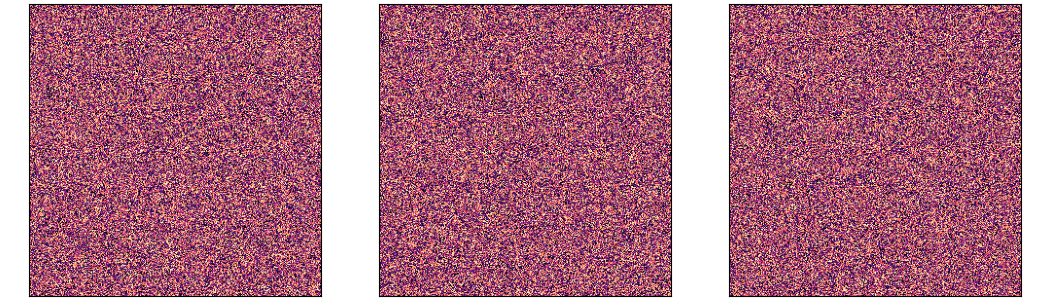

In [5]:
rand_array = np.random.default_rng().random((300, 300, 100, 3))
plotting.images.display_images(rand_array, aspect="equal")

Single image with 2D shape


2026-04-09 15:00:32.415 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:32.417 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin: -99.02, vmax:   19
2026-04-09 15:00:32.418 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to equal.
2026-04-09 15:00:32.429 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (4, 4) and 1 axes.


(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

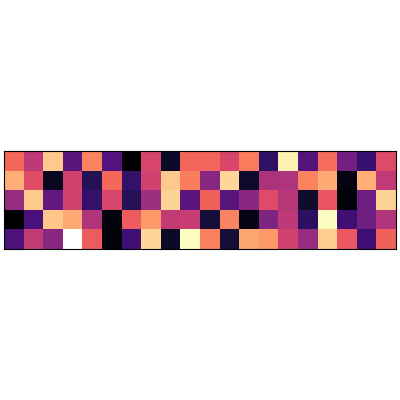

In [6]:
int_array = np.random.default_rng().integers(-100, 20, size=(5, 20))
plotting.images.display_images(int_array, aspect="equal")

Multiple images with 3D shape


2026-04-09 15:00:32.572 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:32.574 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:  -10, vmax:   19
2026-04-09 15:00:32.575 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to equal.
2026-04-09 15:00:32.584 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (4, 4) and 1 axes.


interactive(children=(IntSlider(value=9, description='slice_idx', max=19), Output()), _dom_classes=('widget-in…

(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

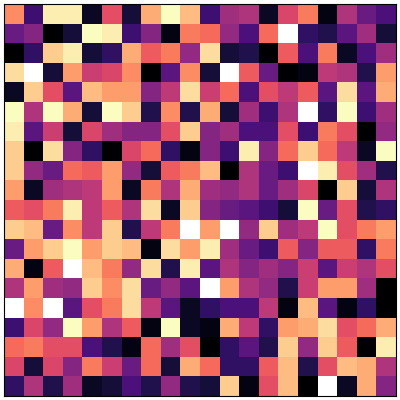

In [7]:
int_array = np.random.default_rng().integers(-10, 20, size=(20, 20, 20))
plotting.images.display_images(int_array, aspect="equal")

4D image sequence


2026-04-09 15:00:33.313 | DEBUG    | mnutils.plotting.images:display_images:139 - Displaying 7 images in a 2x4 grid.
2026-04-09 15:00:33.314 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:33.315 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin: -100, vmax:   18
2026-04-09 15:00:33.316 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to equal.


2026-04-09 15:00:33.363 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (14.0, 6) and 8 axes.


interactive(children=(IntSlider(value=1, description='slice_idx', max=2), Output()), _dom_classes=('widget-int…

(<Figure size 1400x600 with 7 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >], dtype=object))

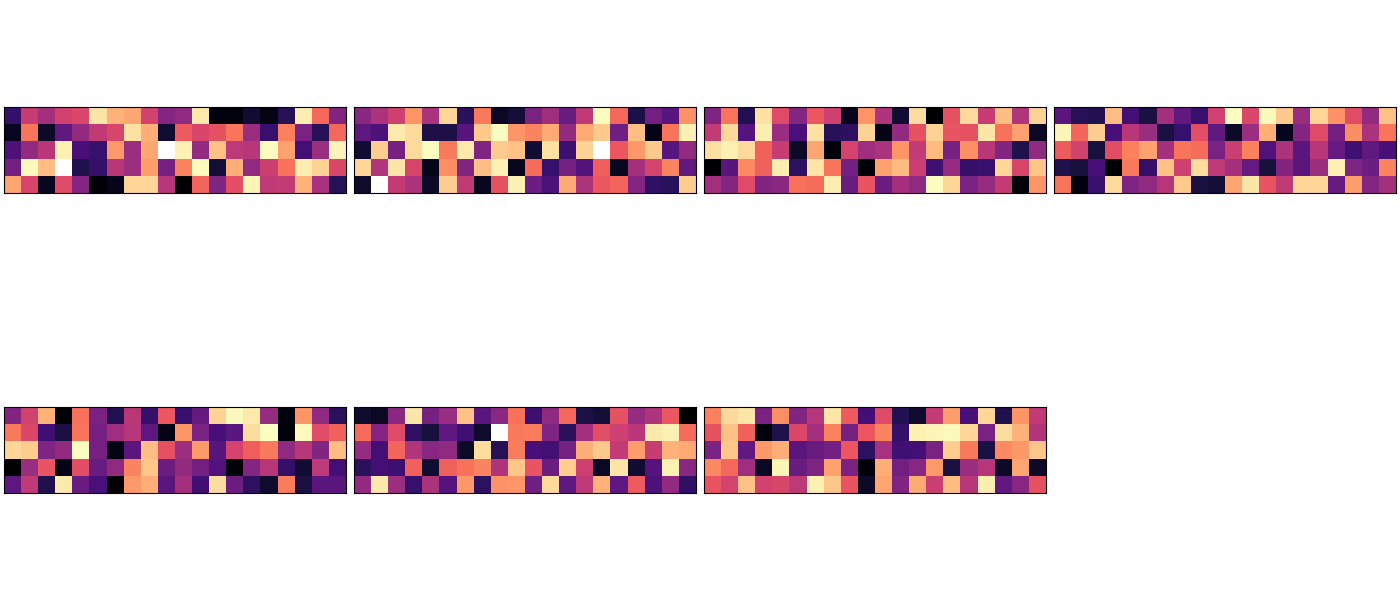

In [8]:
int_array = np.random.default_rng().integers(-100, 20, size=(5, 20, 3, 7))
plotting.images.display_images(int_array, aspect="equal")

2D image with a lot of zeros


2026-04-09 15:00:33.601 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:33.604 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:   -1, vmax:    1
2026-04-09 15:00:33.604 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to 1.0.
2026-04-09 15:00:33.614 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (4, 4) and 1 axes.


(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

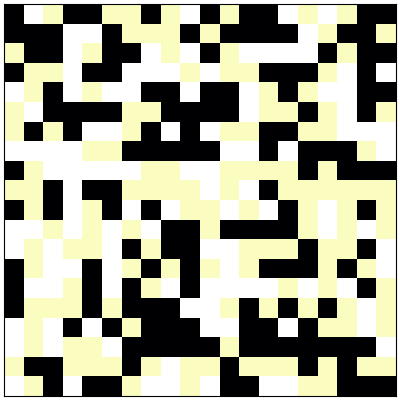

In [9]:
int_array = np.random.default_rng().integers(-1, 2, size=(20, 20))
plotting.images.display_images(int_array)

# Test downsampling and display of MR images


## Folder and Series definitions

Good exams are: HeVo-[18,19,21,24,25,26,27]


In [10]:
cases = [1, 2, 3]
# Folder definitions
BASE_FOLDER = Path(os.getcwd()) / "datasets" / "TestDownSampling"
CASE_FOLDERS = [BASE_FOLDER / f"Case{case}" for case in cases]

In [11]:
exams: list[GEExam.ExamBase] = []
anatomicals: list[GESeries.MRISeries] = []
mrsis: list[GESeries.MRSISeries] = []
bet_niis: list[GESeries.NiiBase] = []

for case_folder in CASE_FOLDERS:
    exam = GEExam.ExamBase(
        case_folder, DATA_FOLDER=case_folder, OUTPUT_FOLDER=case_folder
    )
    exam.load_all()
    anatomical = exam[exam.series[0]]
    anatomicals.append(anatomical)
    mrsis.append(exam[exam.series[1]])  # type: ignore
    brain_mask_path = utils.file_helpers.get_niftis_from_series(
        case_folder,
        anatomical.SERIES_ID,
        filter_out_keywords=[],
        filter_in_keywords=["Y_bet.nii"],
    )
    logger.info(f"Found brain mask for case {case_folder.name}: {brain_mask_path}")
    bet_nii = GESeries.NiiBase(brain_mask_path)
    bet_niis.append(bet_nii)
    exams.append(exam)

2026-04-09 15:00:33.785 | DEBUG    | mnutils.utils.file_helpers:get_all_dicom_series_ids:39 - Found series IDs: [2, 9]
2026-04-09 15:00:33.786 | ERROR    | mnutils.utils.file_helpers:get_all_dicom_series_ids:47 - Missing series IDs: [3, 4, 5, 6, 7, 8]. DOUBLE CHECK DATA FOLDER!


,Has Exam,Has DICOM,Folder Name
Series ID,,,
2,False,True,Series0002_3D_Ax_T1_BRAVO
9,True,True,"Series0009_MRSI_pseudo_S700;X10;Y10;Z10,T1,C1"


2026-04-09 15:00:33.869 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:505 - Color coding: blue = Has Exam Data, orange = Missing DICOM
2026-04-09 15:00:33.869 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:507 - Exam folder path: /home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case1/Exam20328anon
2026-04-09 15:00:33.871 | DEBUG    | mnutils.GEExam:_create_series_dict:102 - Series 2 does not have raw data.
2026-04-09 15:00:33.871 | DEBUG    | mnutils.GEExam:_create_series_dict:114 - Series 9 has both exam and DICOM data. Checking folder name.
2026-04-09 15:00:33.873 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:294 - Filtering NIfTI files in '/home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case1/Series0002_3D_Ax_T1_BRAVO' with keywords not in word: ['bet', 'skullstrip', 'ss', 'resampled'] and keywords in word: []
2026-04-09 15:00:33.874 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:299 - Filter out regex:

,Has Exam,Has DICOM,Folder Name
Series ID,,,
2,False,True,Series0002_3D_Ax_T1_BRAVO
9,True,True,"Series0009_MRSI_pseudo_S700;X10;Y10;Z10,T1,C1"


2026-04-09 15:00:34.573 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:505 - Color coding: blue = Has Exam Data, orange = Missing DICOM
2026-04-09 15:00:34.574 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:507 - Exam folder path: /home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case2/Exam20265anon
2026-04-09 15:00:34.575 | DEBUG    | mnutils.GEExam:_create_series_dict:102 - Series 2 does not have raw data.
2026-04-09 15:00:34.575 | DEBUG    | mnutils.GEExam:_create_series_dict:114 - Series 9 has both exam and DICOM data. Checking folder name.
2026-04-09 15:00:34.577 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:294 - Filtering NIfTI files in '/home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case2/Series0002_3D_Ax_T1_BRAVO' with keywords not in word: ['bet', 'skullstrip', 'ss', 'resampled'] and keywords in word: []
2026-04-09 15:00:34.577 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:299 - Filter out regex:

,Has Exam,Has DICOM,Folder Name
Series ID,,,
2,False,True,002_3D_Ax_T1_BRAVO
8,True,True,008_MRSI_pseudo_S700_X10_Y10_Z10_T1_C1


2026-04-09 15:00:35.293 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:505 - Color coding: blue = Has Exam Data, orange = Missing DICOM
2026-04-09 15:00:35.295 | DEBUG    | mnutils.utils.file_helpers:get_exam_overview:507 - Exam folder path: /home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case3/Exam7396anon
2026-04-09 15:00:35.296 | DEBUG    | mnutils.GEExam:_create_series_dict:102 - Series 2 does not have raw data.
2026-04-09 15:00:35.296 | DEBUG    | mnutils.GEExam:_create_series_dict:114 - Series 8 has both exam and DICOM data. Checking folder name.
2026-04-09 15:00:35.299 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:294 - Filtering NIfTI files in '/home/sbauer/Projects/Coding/MNUtils/tests/datasets/TestDownSampling/Case3/002_3D_Ax_T1_BRAVO' with keywords not in word: ['bet', 'skullstrip', 'ss', 'resampled'] and keywords in word: []
2026-04-09 15:00:35.300 | DEBUG    | mnutils.utils.file_helpers:get_nifti_file:299 - Filter out regex: bet|sku

# Display overlays and anatomical images


In [12]:
# Figure out how big the percentage of nan values in anatomicals images
anatomical_images = anatomicals[0].images()
total_elements = anatomical_images.size
nan_elements = np.isnan(anatomical_images).sum()
zero_elements = (anatomical_images == 0).sum()
nan_percentage = (nan_elements / total_elements) * 100
zero_percentage = (zero_elements / total_elements) * 100
logger.info(
    f"Anatomical image {anatomicals[0].SERIES_ID} has {nan_percentage:.2f}% NaN values, "
    f"{zero_percentage:.2f}% zero values "
    f"(nan: {nan_elements}, zero: {zero_elements}, total: {total_elements})."
)

2026-04-09 15:00:35.994 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.


2026-04-09 15:00:36.584 | INFO     | __main__:<module>:8 - Anatomical image 2 has 0.00% NaN values, 6.49% zero values (nan: 0, zero: 1701233, total: 26214400).


2026-04-09 15:00:36.641 | DEBUG    | mnutils.GESeries:display:108 - Displaying NIfTI with orientation None and display plane None.
2026-04-09 15:00:36.643 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.


2026-04-09 15:00:36.724 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:36.882 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:    8, vmax:  676
2026-04-09 15:00:36.883 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to 1.0.
2026-04-09 15:00:36.894 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (4, 4) and 1 axes.


interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

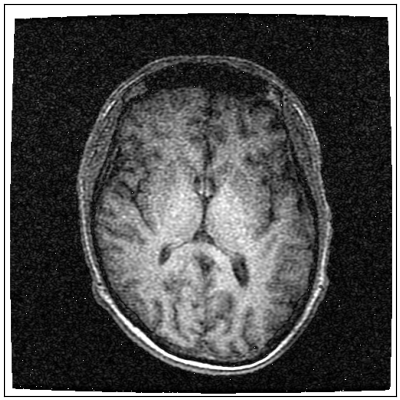

In [13]:
anatomicals[0].display(cmap="gray")

2026-04-09 15:00:37.311 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:37.313 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [1.171875 1.171875] to affine.


2026-04-09 15:00:37.983 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:37.985 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:38.110 | DEBUG    | mnutils.plotting.images:overlay_image_data_on_T1:375 - Displayed T1 image with shape (512, 512, 100) at slice index 50.
2026-04-09 15:00:38.120 | DEBUG    | mnutils.plotting.images:overlay_image_data_on_T1:388 - Displayed resampled data image with shape (512, 512, 100) at slice index 50.
2026-04-09 15:00:38.131 | DEBUG    | mnutils.plotting.images:overlay_image_data_on_T1_on_ax:502 - Setting overlay vmin: 2451.32, vmax: 28841


interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

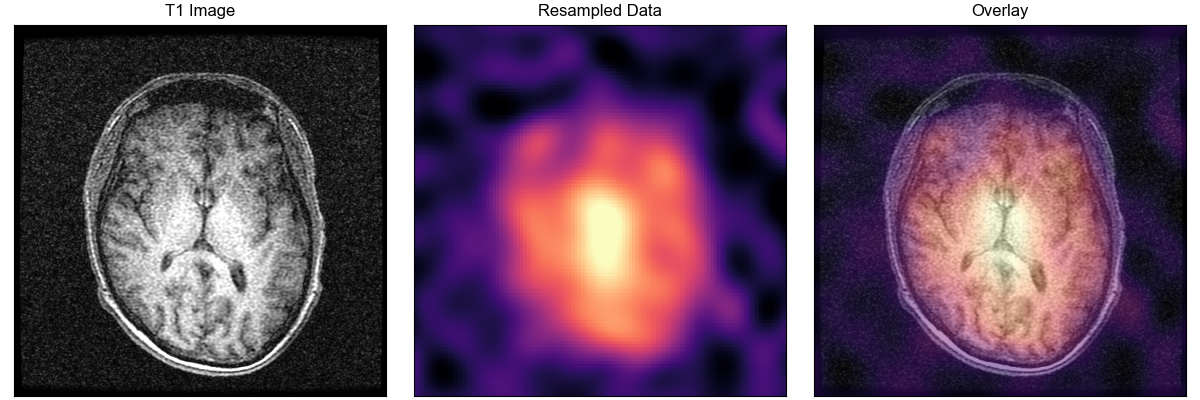

In [14]:
mrsis[0].overlay_on_T1(anatomicals[0])

## Test MRSI inspection

In [15]:
plotting.images.inspect_MRSI_spectra(anatomicals[0], mrsis[0])

2026-04-09 15:00:38.741 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:38.744 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:38.746 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [9.375 9.375] to affine.
2026-04-09 15:00:39.413 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:39.415 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:39.547 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [9.375 9.375] to affine.
2026-04-09 15:00:39.548 | DEBUG    | mnuti

## Display MRSI abs image

2026-04-09 15:00:39.980 | DEBUG    | mnutils.GESeries:display:108 - Displaying NIfTI with orientation None and display plane None.
2026-04-09 15:00:39.982 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:39.983 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:39.984 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin: 1.00119e+09, vmax: 1.20323e+09
2026-04-09 15:00:39.984 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to 1.0.
2026-04-09 15:00:40.000 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (4, 4) and 1 axes.


interactive(children=(IntSlider(value=7, description='slice_idx', max=15), Output()), _dom_classes=('widget-in…

(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

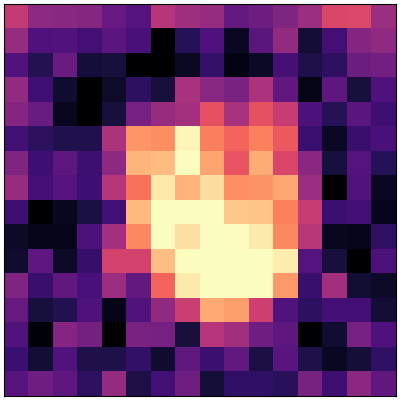

In [16]:
mrsis[0].RAW_exp.display()

## Create a mask based on voxel selection and overlay mask on anatomical images


2026-04-09 15:00:40.888 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:40.890 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:41.288 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:43.008 | DEBUG    | mnutils.plotting.images:display_images:139 - Displaying 3 images in a 1x3 grid.
2026-04-09 15:00:43.009 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:00:43.292 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:   30, vmax: 1300
2026-04-09 15:00:43.293 | DEBUG    | mnutils.plotting.images:display_images:

interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 1050x300 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

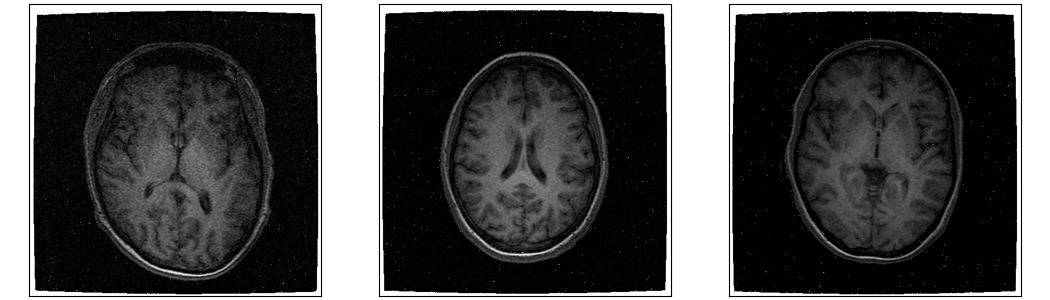

In [17]:
plotting.images.display_images(
    [anatomical.images() for anatomical in anatomicals],
    v_percentile=0,
    zeros_as_nan=True,
    cmap="gray",
    vmin=30,
    vmax=1300,
)

Load brain mask (BET)


Do a simple left-right split of the brain and display both halves separately


### Show masked anatomical images for visual verification


In [18]:
all_brain_extracted = [
    anatomical.images() * bet_nii.images().astype(bool)
    for anatomical, bet_nii in zip(anatomicals, bet_niis)
]

2026-04-09 15:00:43.848 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:43.850 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:44.397 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:44.399 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:44.937 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:44.939 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may u

2026-04-09 15:00:46.519 | DEBUG    | mnutils.plotting.images:display_images:139 - Displaying 3 images in a 1x3 grid.
2026-04-09 15:00:46.520 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:   50, vmax:  600
2026-04-09 15:00:46.521 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to 1.0.
2026-04-09 15:00:46.543 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (10.5, 3) and 3 axes.


interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 1050x300 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

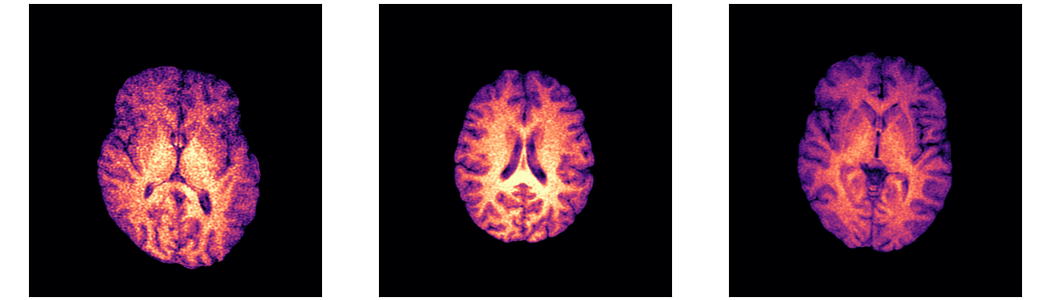

In [19]:
plotting.images.display_images(all_brain_extracted, vmin=50, vmax=600)

# Verify that overlays look proper

These look okay!


2026-04-09 15:00:46.969 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:46.971 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [9.375 9.375] to affine.
2026-04-09 15:00:47.650 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:47.677 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [0.25 0.25] to affine.
2026-04-09 15:00:48.329 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:48.330 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:48.412 | DEBUG    | mnutils.plotting.images:overlay_i

interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

2026-04-09 15:00:48.431 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:48.433 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [9.375 9.375] to affine.
2026-04-09 15:00:49.084 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:49.110 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [0.25 0.25] to affine.
2026-04-09 15:00:49.757 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:49.759 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:49.875 | DEBUG    | mnutils.plotting.images:overlay_i

interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

2026-04-09 15:00:49.894 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:49.896 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [9.375 9.375] to affine.
2026-04-09 15:00:50.554 | DEBUG    | mnutils.utils.nifti:resample_nifti:99 - Resampling with parameters: {'order': 0, 'mode': 'constant', 'cval': nan}
2026-04-09 15:00:50.578 | DEBUG    | mnutils.utils.nifti:apply_half_voxel_shift:85 - Applied half voxel shift of [0.25 0.25] to affine.
2026-04-09 15:00:51.399 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:51.400 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:00:53.329 | DEBUG    | mnutils.plotting.images:overlay_i

interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

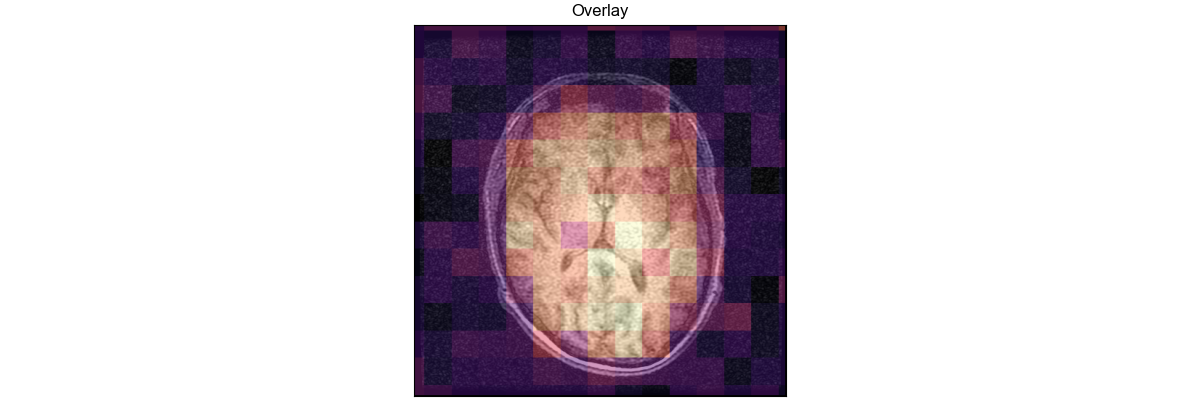

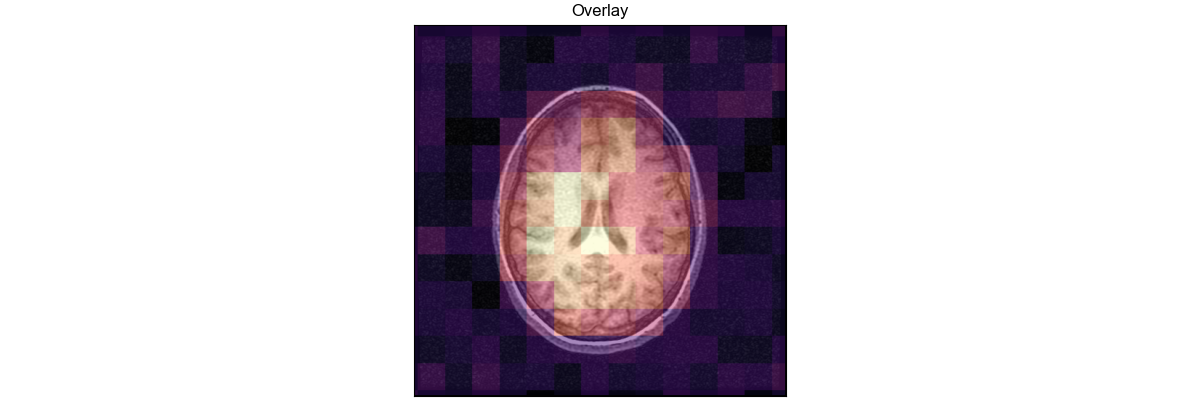

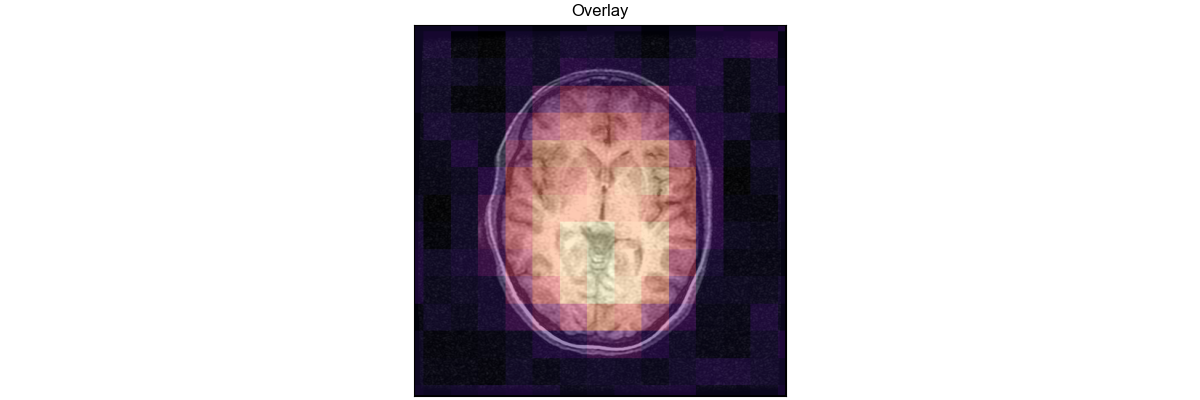

In [20]:
for anatomical, mrsi in zip(anatomicals, mrsis):
    resampled_blocky = mrsi.RAW_exp.resample_self_to(anatomical, order=0)
    resampled_blocky.overlay_on_T1(anatomical, only_overlay=True)

## Downsample masks to MRSI resolution and display them on anatomical images for visual verification


2026-04-09 15:00:54.400 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:01:02.157 | DEBUG    | mnutils.plotting.images:display_images:139 - Displaying 4 images in a 1x4 grid.
2026-04-09 15:01:02.158 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:    0, vmax:    1
2026-04-09 15:01:02.159 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image aspect ratio to 1.0.
2026-04-09 15:01:02.186 | DEBUG    | mnutils.plotting.images:display_images:224 - Created figure with size (14.0, 3) and 4 axes.


interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 1400x300 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

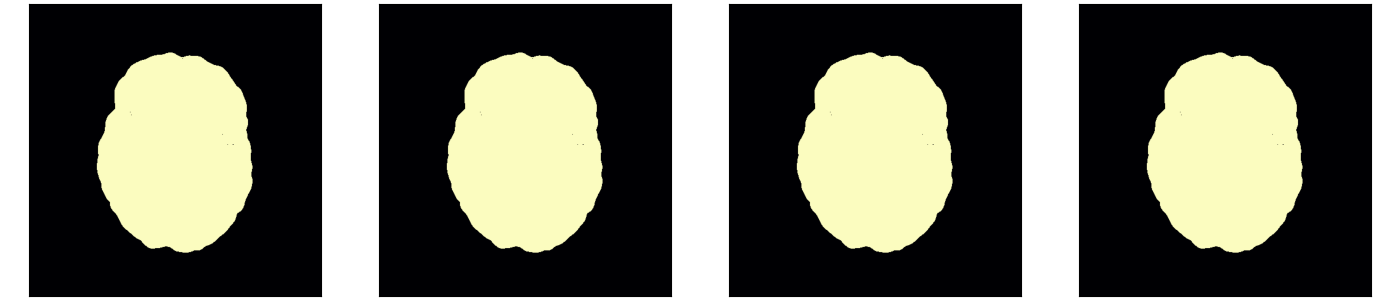

In [21]:
plotting.images.display_images(4 * [bet_nii.images().astype(bool)], vmin=0, vmax=1)

2026-04-09 15:01:03.008 | DEBUG    | mnutils.utils.nifti:orient_nifti:55 - Using caching for NIfTI data. This may use more memory but can speed up processing for repeat access.
2026-04-09 15:01:03.303 | DEBUG    | mnutils.plotting.images:display_images:151 - Setting 0 values in images to NaN for better visualization and colorbar scaling.
2026-04-09 15:01:04.808 | DEBUG    | mnutils.plotting.images:display_images:175 - vmin (1.0) and vmax (1.0) are equal or NaN. Adjusting vmin and vmax to the min and max of the images for better visualization.
2026-04-09 15:01:04.825 | DEBUG    | mnutils.plotting.images:display_images:181 - vmin and vmax are still equal after adjustment. This is likely to all non zeros values being equal (e.g. in a mask). Setting vmin to 0 for better visualization.
2026-04-09 15:01:04.826 | DEBUG    | mnutils.plotting.images:display_images:186 - Setting vmin:    0, vmax:    1
2026-04-09 15:01:04.827 | DEBUG    | mnutils.plotting.images:display_images:191 - Setting image

interactive(children=(IntSlider(value=49, description='slice_idx', max=99), Output()), _dom_classes=('widget-i…

(<Figure size 400x400 with 1 Axes>, array([<Axes: >], dtype=object))

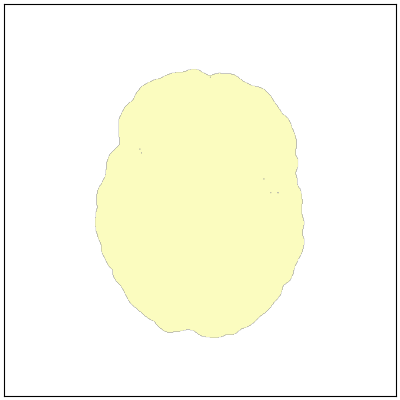

In [22]:
images = bet_nii.images().astype(bool).copy()
plotting.images.display_images(images)